# 제조 데이터 전처리 (2)

**스케일링, 인코딩, 특성 엔지니어링**

---

# 지난 시간 복기

지난 시간에, **수치형 데이터**에 대한 전처리 내용들을 다루었음

### 결측치 처리
- `isnull()`, `fillna()`, `dropna()`
- 수치형: 평균/중앙값, 범주형: 최빈값

### 이상치 처리
- IQR: Q1 - 1.5×IQR ~ Q3 + 1.5×IQR
- Z-score: |Z| > 2 또는 3
- Clipping, 제거, 플래그 등..

# 학습 목표


1. **스케일링(정규화, 표준화)의 필요성을 이해**한다
2. **범주형 데이터 인코딩 방법**을 적용한다
3. **sklearn 전처리 도구**를 활용해본다

## 1. 스케일링(정규화, 표준화)의 필요성 이해

## 왜 스케일링이 필요한가?

### 제조 데이터의 스케일 차이

```
온도:     80 ~ 100    (범위 20)
생산량:   1000 ~ 1500 (범위 500)
습도:     40 ~ 80     (범위 40)
불량률:   0.01 ~ 0.05 (범위 0.04)
```

### 문제점
- 스케일이 큰 변수가 모델에 **과도한 영향**
- 거리 기반 알고리즘에서 **왜곡**
- 경사하강법 **수렴 속도 저하**

---

# 스케일링이 필요한 알고리즘

## 스케일 영향을 받는 알고리즘

| 알고리즘 | 스케일링 필요성 | 이유 |
|----------|:-------------:|------|
| KNN | **필수** | 거리 계산에 직접 영향 |
| SVM | **필수** | 서포트 벡터 결정에 영향 |
| 선형회귀 | 권장 | 계수 해석, 수렴 속도 |
| 신경망 | **필수** | 활성화 함수, 경사하강법 |
| 의사결정나무 | 불필요 | 분기점 기반 (순위만 사용) |
| 랜덤포레스트 | 불필요 | 트리 기반 앙상블 |

> 어떤 경우에 스케일링이 필요하고, 어떤 경우에 불필요할까?

# 스케일링 미적용 시 문제

## 거리 기반 알고리즘 예시

```python
# 두 제품 간 거리 계산 (스케일링 없이)
제품A: [온도=80, 생산량=1000]
제품B: [온도=90, 생산량=1200]

거리 = √((90-80)² + (1200-1000)²)
     = √(100 + 40000)
     = √40100 ≈ 200.25
```

### 문제점
- 온도 차이(10) vs 생산량 차이(200)
- **생산량 변수가 거리 변수에 대해 지배적으로동작** → 온도 영향력 무시됨

# 표준화 (Standardization)

## Z-score 변환

### 공식
$$Z = \frac{X - \mu}{\sigma}$$

- μ: 평균 (mean)
- σ: 표준편차 (std)

### 결과
- **평균 = 0**
- **표준편차 = 1**
- 값의 범위: 대략 -3 ~ +3 (정규분포 가정)



> 참고! 표준화(Standardization)화 정규화(Normalization)차이. 가끔 한글에서는 이 둘을 같은 용어로 사용하기도 하고 혼동에 유의한다

### 1) Standardization (표준화)

* 목적: **스케일을 평균 0, 표준편차 1**에 맞춰 비교 가능하게 만들기
* 대표식(Z-score):
  $$z=\frac{x-\mu}{\sigma}$$
* 결과 범위: **제한 없음** (음수/양수 모두 가능, 0~1로 안 묶임)
* 자주 쓰는 곳: 선형모델(회귀/로지스틱), SVM, PCA, k-means 등 “거리/분산/정규성”에 민감한 모델에서 자주 사용

### 2) Normalization (정규화)

Normalization은 “정규화”라는 번역이 **가장 많이 섞여 쓰이는** 쪽인데, 최소 2~3가지 의미가 있을 수 있음

#### (A) Min-Max Scaling (흔히 말하는 0~1 정규화)

* 대표식:
  $$x'=\frac{x-\min(x)}{\max(x)-\min(x)}$$
  
* 결과 범위: **보통 [0,1]** (혹은 [-1,1] 같은 다른 구간으로도 가능)
* “0~1 사이의 임의 실수로 배당”은 **대부분 이 케이스**를 말하는 경우가 많음

#### (B) Vector Normalization (노름 정규화)

* 예: L2 정규화
  $$\mathbf{x}'=\frac{\mathbf{x}}{|\mathbf{x}|_2}$$
  
* 결과: 각 벡터의 크기(길이)를 1로 맞춤. 값이 꼭 0~1 범위인 건 **아님**.
* (단, 위와 같이, 평균이나 표준편차의 개념과는 관계가 없고 벡터의 길이와 연계된 개념임)

#### (C) (참고) DB 정규화

* 데이터베이스의 정규화(1NF, 2NF…)는 완전히 다른 의미라 문맥으로 분리해야 할 수 있음. 컴퓨터 사이언스에서 여러 의미로 정규화라는 단어가 사용될 수 있는데, 전부 뉘앙스가 다를 수 있음에 유의할 것

* **표준화(Standardization)**: “평균 0, 표준편차 1”로 맞춤 → 범위 제한 없음
* **정규화(Normalization)**: (자주) “0~1로 스케일링”이지만, 문맥에 따라 “노름으로 나누기” 등도 포함


## 실습 데이터: AI4I 2020 Predictive Maintenance Dataset

본 실습에서는 UCI Machine Learning Repository에서 제공하는 **AI4I 2020 Predictive Maintenance Dataset**을 사용함. 이 데이터셋은 Industry 4.0 환경의 **예측 유지보수(Predictive Maintenance)** 연구를 위해 설계되었으며, 실제 제조 환경의 센서 특성을 반영하여 생성된 합성 데이터임.

**데이터 URL**: https://archive.ics.uci.edu/ml/datasets/AI4I+2020+Predictive+Maintenance+Dataset

### 변수 설명

| 변수명 | 설명 | 데이터 유형 | 단위 |
|--------|------|-------------|------|
| `UDI` | 고유 식별자 (1~10000) | 정수형 | - |
| `Product ID` | 제품 ID (품질등급 + 일련번호) | 문자열 | - |
| `Type` | 제품 품질 등급 | **범주형** | L/M/H |
| `Air temperature [K]` | 공기 온도 | 수치형 | 켈빈(K) |
| `Process temperature [K]` | 공정 온도 | 수치형 | 켈빈(K) |
| `Rotational speed [rpm]` | 회전 속도 | 수치형 | rpm |
| `Torque [Nm]` | 토크 | 수치형 | Nm |
| `Tool wear [min]` | 공구 마모 시간 | 수치형 | 분 |
| `Machine failure` | 기계 고장 여부 (타겟) | 이진형 | 0/1 |

### 품질 등급(Type) 분포

| 등급 | 의미 | 비율 |
|------|------|------|
| L | Low Quality | 60% |
| M | Medium Quality | 30% |
| H | High Quality | 10% |

### 실습 환경 설정 및 데이터 로드

In [3]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
# AI4I 2020 데이터셋 로드
# UCI ML Repository에서 직접 다운로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print("=" * 60)
print("AI4I 2020 Predictive Maintenance Dataset")
print("=" * 60)
print(f"데이터 크기: {df.shape[0]:,}개 샘플, {df.shape[1]}개 변수")
print(f"\n변수 목록:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

AI4I 2020 Predictive Maintenance Dataset
데이터 크기: 10,000개 샘플, 14개 변수

변수 목록:
   1. UDI
   2. Product ID
   3. Type
   4. Air temperature [K]
   5. Process temperature [K]
   6. Rotational speed [rpm]
   7. Torque [Nm]
   8. Tool wear [min]
   9. Machine failure
  10. TWF
  11. HDF
  12. PWF
  13. OSF
  14. RNF


### 데이터 탐색 및 스케일 차이 확인

In [3]:
# 수치형 변수 선택
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

print("=" * 70)
print("수치형 변수별 기초 통계량")
print("=" * 70)
stats = df[numeric_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats['cv'] = (stats['std'] / stats['mean'] * 100).round(2)  # 변동계수(%)
print(stats[['mean', 'std', 'min', 'max', 'range', 'cv']].round(2))

수치형 변수별 기초 통계량
                            mean     std     min     max   range     cv
Air temperature [K]       300.00    2.00   295.3   304.5     9.2   0.67
Process temperature [K]   310.01    1.48   305.7   313.8     8.1   0.48
Rotational speed [rpm]   1538.78  179.28  1168.0  2886.0  1718.0  11.65
Torque [Nm]                39.99    9.97     3.8    76.6    72.8  24.93
Tool wear [min]           107.95   63.65     0.0   253.0   253.0  58.97


**핵심 관찰**:
- **회전 속도(rpm)**: 범위가 1,718로 가장 넓음
- **공구 마모(min)**: 범위 253, 변동계수 58.3%로 변동성이 큼
- **온도 변수들**: 범위가 약 8~9로 매우 좁음

이러한 스케일 차이가 머신러닝 모델에 미치는 영향을 이해해야 함.

### 스케일 차이가 발생시키는 문제

#### 문제 1: 거리 기반 알고리즘의 왜곡

유클리드 거리(Euclidean Distance) 공식:

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

두 샘플 간 차이가 다음과 같을 때:
- 온도 차이: 2K
- 회전 속도 차이: 100rpm

거리 계산 결과:

$$d = \sqrt{2^2 + 100^2} = \sqrt{4 + 10000} = \sqrt{10004} \approx 100.02$$

온도 차이의 기여분 $2^2 = 4$는 회전 속도 기여분 $100^2 = 10000$에 비해 **0.04%에 불과**함. 즉, 온도 정보가 사실상 무시됨.

In [4]:
# 스케일 차이로 인한 거리 왜곡 시연
sample1 = df.iloc[0][numeric_cols].values
sample2 = df.iloc[1][numeric_cols].values

# 각 변수별 차이의 제곱
squared_diffs = (sample1 - sample2) ** 2
total_distance = np.sqrt(np.sum(squared_diffs))

print("=" * 60)
print("거리 계산에서 각 변수의 기여도 분석")
print("=" * 60)
print(f"{'변수':<30} {'차이²':>12} {'기여율(%)':>10}")
print("-" * 60)
for col, sq_diff in zip(numeric_cols, squared_diffs):
    contribution = sq_diff / np.sum(squared_diffs) * 100
    print(f"{col:<30} {sq_diff:>12.2f} {contribution:>10.2f}")
print("-" * 60)
print(f"{'유클리드 거리':<30} {total_distance:>12.2f}")

거리 계산에서 각 변수의 기여도 분석
변수                                      차이²     기여율(%)
------------------------------------------------------------
Air temperature [K]                    0.01       0.00
Process temperature [K]                0.01       0.00
Rotational speed [rpm]             20449.00      99.90
Torque [Nm]                           12.25       0.06
Tool wear [min]                        9.00       0.04
------------------------------------------------------------
유클리드 거리                              143.07


#### 회전 속도와 공구 마모 시간이 거리 계산의 대부분을 지배하며, 온도 변수들의 정보는 거의 반영되지 않음.

#### 문제 2: 경사하강법 수렴 속도 저하 -> 나중에 AI 학습과 관련된 부분

경사하강법(Gradient Descent)에서 가중치 업데이트 공식:

$$\mathbf{w}_{new} = \mathbf{w}_{old} - \eta \cdot \nabla L(\mathbf{w})$$

여기서:
- $\eta$: 학습률 (learning rate)
- $\nabla L(\mathbf{w})$: 손실 함수의 기울기

스케일이 다른 특성들이 있으면, **손실 함수의 등고선(contour)이 타원형**으로 늘어짐:

```
스케일 불균형 시          스케일 균형 시
    ╱╲                      ○
   ╱  ╲                    ╱ ╲
  ╱    ╲                  ╱   ╲
 ╱      ╲                ○     ○
 ╲      ╱                 ╲   ╱
  ╲    ╱                   ╲ ╱
   ╲  ╱                     ○
    ╲╱
(지그재그 경로)          (직선 경로)
```

결과적으로 **수렴에 더 많은 반복이 필요**하거나 발산할 수 있음.

#### 문제 3: 정규화(Regularization) 불공정

L2 정규화(Ridge Regression)의 손실 함수:

$$L = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}w_j^2$$

스케일이 큰 변수(예: rpm)는 **작은 계수로도 큰 예측값**을 만들 수 있음:
- 회전 속도 1500rpm × 계수 0.01 = 기여분 15
- 온도 300K × 계수 0.01 = 기여분 3

동일한 계수 크기(0.01)에 동일한 정규화 페널티가 적용되지만, 실제 기여도는 5배 차이남.

# 1. 표준화 (Standardization / Z-score Normalization)

**수식 정의**:

$$z = \frac{x - \mu}{\sigma}$$

**구성 요소**:

표본 평균 (Sample Mean):
$$\mu = \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$$

표본 표준편차 (Sample Standard Deviation):
$$\sigma = s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

**[참고] sklearn의 StandardScaler는 모표준편차(n으로 나눔)를 사용함**:
$$\sigma_{sklearn} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

**변환 후 특성**:
- 평균: $E[z] = 0$
- 분산: $Var(z) = 1$

**증명**:

평균이 0이 됨을 보이면:
$$E[z] = E\left[\frac{x - \mu}{\sigma}\right] = \frac{1}{\sigma}(E[x] - \mu) = \frac{1}{\sigma}(\mu - \mu) = 0$$

분산이 1이 됨을 보이면:
$$Var(z) = Var\left(\frac{x - \mu}{\sigma}\right) = \frac{1}{\sigma^2}Var(x) = \frac{\sigma^2}{\sigma^2} = 1$$

In [5]:
# 수치 예시: 회전 속도 데이터로 표준화 계산
rpm_data = df['Rotational speed [rpm]'].values[:5]
print("원본 데이터:", rpm_data)

# 수동 계산
mu = np.mean(rpm_data)
sigma = np.std(rpm_data, ddof=0)  # sklearn과 동일하게 모표준편차 사용
z_manual = (rpm_data - mu) / sigma

print(f"\n평균 (μ) = {mu:.2f}")
print(f"표준편차 (σ) = {sigma:.2f}")
print(f"\n표준화 결과:")
for i, (orig, z) in enumerate(zip(rpm_data, z_manual)):
    calc = f"({orig} - {mu:.2f}) / {sigma:.2f}"
    print(f"  x[{i}] = {orig:>6} → z[{i}] = {calc} = {z:.4f}")

# 검증
print(f"\n변환 후 평균: {np.mean(z_manual):.6f} (≈ 0)")
print(f"변환 후 표준편차: {np.std(z_manual):.6f} (≈ 1)")

원본 데이터: [1551 1408 1498 1433 1408]

평균 (μ) = 1459.60
표준편차 (σ) = 56.32

표준화 결과:
  x[0] =   1551 → z[0] = (1551 - 1459.60) / 56.32 = 1.6228
  x[1] =   1408 → z[1] = (1408 - 1459.60) / 56.32 = -0.9162
  x[2] =   1498 → z[2] = (1498 - 1459.60) / 56.32 = 0.6818
  x[3] =   1433 → z[3] = (1433 - 1459.60) / 56.32 = -0.4723
  x[4] =   1408 → z[4] = (1408 - 1459.60) / 56.32 = -0.9162

변환 후 평균: 0.000000 (≈ 0)
변환 후 표준편차: 1.000000 (≈ 1)


# 2. 최소-최대 정규화 (Min-Max Normalization)

**수식 정의**:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**일반화된 형태** (임의의 범위 [a, b]로 변환):

$$x_{scaled} = a + \frac{(x - x_{min})(b - a)}{x_{max} - x_{min}}$$

**변환 후 특성**:
- 최솟값: 0 (또는 a)
- 최댓값: 1 (또는 b)
- 원본 분포의 **형태(shape) 유지**
- 이상치에 **민감함**

In [6]:
# 수치 예시: 토크 데이터로 Min-Max 정규화
torque_data = df['Torque [Nm]'].values[:5]
print("원본 데이터:", torque_data.round(2))

x_min = np.min(torque_data)
x_max = np.max(torque_data)
range_val = x_max - x_min

mm_manual = (torque_data - x_min) / range_val

print(f"\n최솟값 = {x_min:.2f}")
print(f"최댓값 = {x_max:.2f}")
print(f"범위 = {range_val:.2f}")
print(f"\nMin-Max 정규화 결과:")
for i, (orig, mm) in enumerate(zip(torque_data, mm_manual)):
    print(f"  x[{i}] = {orig:>6.2f} → scaled[{i}] = {mm:.4f}")

원본 데이터: [42.8 46.3 49.4 39.5 40. ]

최솟값 = 39.50
최댓값 = 49.40
범위 = 9.90

Min-Max 정규화 결과:
  x[0] =  42.80 → scaled[0] = 0.3333
  x[1] =  46.30 → scaled[1] = 0.6869
  x[2] =  49.40 → scaled[2] = 1.0000
  x[3] =  39.50 → scaled[3] = 0.0000
  x[4] =  40.00 → scaled[4] = 0.0505


# 3. 로버스트 스케일링 (Robust Scaling)

**수식 정의**:

$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1} = \frac{x - \text{median}}{\text{IQR}}$$

**구성 요소**:
- $Q_1$: 제1사분위수 (25th percentile)
- $Q_2$: 제2사분위수 = 중앙값 (50th percentile)  
- $Q_3$: 제3사분위수 (75th percentile)
- $\text{IQR} = Q_3 - Q_1$: 사분위범위 (Interquartile Range)

**변환 후 특성**:
- 중앙값: 0
- IQR: 1
- **이상치에 강건함** (평균/표준편차 대신 중앙값/IQR 사용)

**이상치 강건성의 원리**:

평균과 표준편차는 이상치에 민감함:
- 데이터 [1, 2, 3, 4, 100] → 평균 = 22, 표준편차 ≈ 41.5

중앙값과 IQR은 이상치에 강건함:
- 동일 데이터 → 중앙값 = 3, IQR = 2.5

In [7]:
# 이상치가 있는 상황에서 스케일러 비교
# 공구 마모 데이터에 인위적 이상치 추가
tool_wear_sample = df['Tool wear [min]'].values[:10].copy().astype(float)
tool_wear_sample[-1] = 1000  # 이상치 추가

print("이상치 포함 데이터:", tool_wear_sample)
print(f"\n평균: {np.mean(tool_wear_sample):.2f}, 표준편차: {np.std(tool_wear_sample):.2f}")
print(f"중앙값: {np.median(tool_wear_sample):.2f}, IQR: {np.percentile(tool_wear_sample, 75) - np.percentile(tool_wear_sample, 25):.2f}")

이상치 포함 데이터: [   0.    3.    5.    7.    9.   11.   14.   16.   18. 1000.]

평균: 108.30, 표준편차: 297.28
중앙값: 10.00, IQR: 10.00


### 스케일링 방법 비교

| 방법 | 수식 | 결과 범위 | 적합한 상황 | 이상치 민감도 |
|------|------|----------|------------|--------------|
| **StandardScaler** | $(x-\mu)/\sigma$ | 평균=0, std=1 | 정규분포 가정, 일반적 ML | 높음 |
| **MinMaxScaler** | $(x-min)/(max-min)$ | [0, 1] | 신경망, 이미지 데이터 | 매우 높음 |
| **RobustScaler** | $(x-Q_2)/IQR$ | 중앙값=0 | 이상치 많을 때 | 낮음 |

### 세 가지 스케일러 적용

In [10]:
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rb = RobustScaler()

# 수치형 데이터 추출
X_numeric = df[numeric_cols].values

# 스케일링 적용
X_std = scaler_std.fit_transform(X_numeric)
X_mm = scaler_mm.fit_transform(X_numeric)
X_rb = scaler_rb.fit_transform(X_numeric)

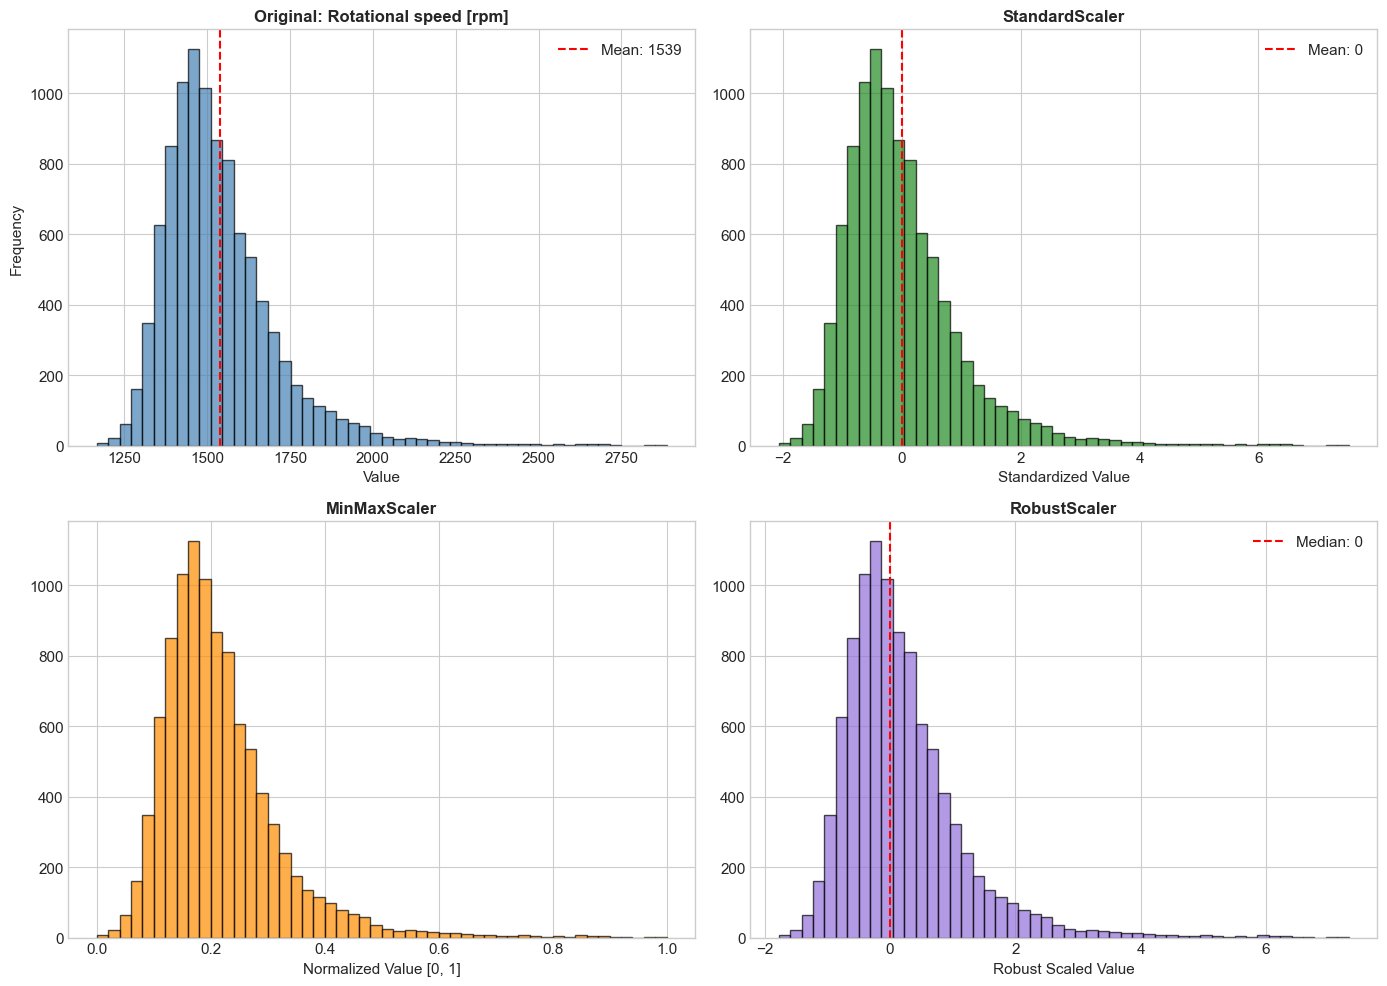


[그림 해석]
- 분포의 '형태'는 모든 스케일링에서 동일하게 유지됨
- StandardScaler: 평균이 0으로 이동, 표준편차가 1로 조정됨
- MinMaxScaler: 값이 [0, 1] 범위로 압축됨
- RobustScaler: 중앙값이 0으로 이동, IQR이 1로 조정됨


In [11]:
# 결과 비교 (회전 속도 컬럼)
rpm_idx = 2  # 'Rotational speed [rpm]'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 원본
axes[0, 0].hist(X_numeric[:, rpm_idx], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Original: Rotational speed [rpm]', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(np.mean(X_numeric[:, rpm_idx]), color='red', linestyle='--', label=f'Mean: {np.mean(X_numeric[:, rpm_idx]):.0f}')
axes[0, 0].legend()

# StandardScaler
axes[0, 1].hist(X_std[:, rpm_idx], bins=50, edgecolor='black', alpha=0.7, color='forestgreen')
axes[0, 1].set_title('StandardScaler', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Standardized Value')
axes[0, 1].axvline(0, color='red', linestyle='--', label='Mean: 0')
axes[0, 1].legend()

# MinMaxScaler
axes[1, 0].hist(X_mm[:, rpm_idx], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1, 0].set_title('MinMaxScaler', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Normalized Value [0, 1]')

# RobustScaler
axes[1, 1].hist(X_rb[:, rpm_idx], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1, 1].set_title('RobustScaler', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Robust Scaled Value')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Median: 0')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n[그림 해석]")
print("- 분포의 '형태'는 모든 스케일링에서 동일하게 유지됨")
print("- StandardScaler: 평균이 0으로 이동, 표준편차가 1로 조정됨")
print("- MinMaxScaler: 값이 [0, 1] 범위로 압축됨")
print("- RobustScaler: 중앙값이 0으로 이동, IQR이 1로 조정됨")

In [13]:
# 스케일링 전후 통계 비교
print("스케일링 전후 통계")

for i, col in enumerate(numeric_cols):
    print(f"\n{col}:")
    print(f"  {'방법':<15} {'평균':>12} {'표준편차':>12} {'최솟값':>12} {'최댓값':>12}")
    print(f"  {'-'*60}")
    print(f"  {'원본':<15} {np.mean(X_numeric[:, i]):>12.2f} {np.std(X_numeric[:, i]):>12.2f} {np.min(X_numeric[:, i]):>12.2f} {np.max(X_numeric[:, i]):>12.2f}")
    print(f"  {'StandardScaler':<15} {np.mean(X_std[:, i]):>12.4f} {np.std(X_std[:, i]):>12.4f} {np.min(X_std[:, i]):>12.4f} {np.max(X_std[:, i]):>12.4f}")
    print(f"  {'MinMaxScaler':<15} {np.mean(X_mm[:, i]):>12.4f} {np.std(X_mm[:, i]):>12.4f} {np.min(X_mm[:, i]):>12.4f} {np.max(X_mm[:, i]):>12.4f}")
    print(f"  {'RobustScaler':<15} {np.mean(X_rb[:, i]):>12.4f} {np.std(X_rb[:, i]):>12.4f} {np.min(X_rb[:, i]):>12.4f} {np.max(X_rb[:, i]):>12.4f}")

스케일링 전후 통계

Air temperature [K]:
  방법                        평균         표준편차          최솟값          최댓값
  ------------------------------------------------------------
  원본                    300.00         2.00       295.30       304.50
  StandardScaler       -0.0000       1.0000      -2.3523       2.2474
  MinMaxScaler          0.5114       0.2174       0.0000       1.0000
  RobustScaler         -0.0297       0.6250      -1.5000       1.3750

Process temperature [K]:
  방법                        평균         표준편차          최솟값          최댓값
  ------------------------------------------------------------
  원본                    310.01         1.48       305.70       313.80
  StandardScaler        0.0000       1.0000      -2.9020       2.5575
  MinMaxScaler          0.5316       0.1832       0.0000       1.0000
  RobustScaler         -0.0411       0.6451      -1.9130       1.6087

Rotational speed [rpm]:
  방법                        평균         표준편차          최솟값          최댓값
  ------------------

### 역변환 (Inverse Transform)

스케일링된 데이터를 원래 스케일로 복원하는 방법:

- 예측 결과를 원래 단위로 해석할 때
- 모델 설명(Explainability)에서 원본 스케일 필요 시
- 시각화에서 직관적인 값 표시 필요 시

In [14]:
X_sample = X_numeric[:3]  # 처음 3개 샘플
X_sample_std = scaler_std.transform(X_sample)
X_restored = scaler_std.inverse_transform(X_sample_std)

print("=" * 60)
print("역변환 검증 (StandardScaler)")
print("=" * 60)
print("\n원본 데이터:")
print(pd.DataFrame(X_sample, columns=numeric_cols).round(2))
print("\n표준화 후:")
print(pd.DataFrame(X_sample_std, columns=numeric_cols).round(4))
print("\n역변환 후:")
print(pd.DataFrame(X_restored, columns=numeric_cols).round(2))
print("\n차이 (원본 - 역변환):")
print(pd.DataFrame(X_sample - X_restored, columns=numeric_cols).round(10))

역변환 검증 (StandardScaler)

원본 데이터:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                  1551.0   
1                298.2                    308.7                  1408.0   
2                298.1                    308.5                  1498.0   

   Torque [Nm]  Tool wear [min]  
0         42.8              0.0  
1         46.3              3.0  
2         49.4              5.0  

표준화 후:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0              -0.9524                  -0.9474                  0.0682   
1              -0.9024                  -0.8800                 -0.7295   
2              -0.9524                  -1.0148                 -0.2274   

   Torque [Nm]  Tool wear [min]  
0       0.2822          -1.6960  
1       0.6333          -1.6489  
2       0.9443          -1.6174  

역변환 후:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0 

## 2. 범주형 데이터 인코딩 방법

### 범주형 데이터란 무엇인가

범주형 데이터(Categorical Data)는 **유한한 개수의 고유값(category)**을 가지는 데이터 유형임. 수치형 데이터와 달리 산술 연산(덧셈, 뺄셈 등)이 의미를 가지지 않음

**제조 현장의 범주형 데이터 예시**:

| 변수 | 고유값 예시 | 특성 |
|------|------------|------|
| 제품 등급 | L, M, H | 품질 순서 존재 |
| 생산 라인 | Line-A, Line-B, Line-C | 순서 없음 |
| 작업 시프트 | 주간, 야간 | 이진 범주 |
| 불량 유형 | 스크래치, 기포, 변형, 오염 | 순서 없음 |
| 작업자 ID | OP001, OP002, ..., OP150 | 고유값 다수 |

### 범주형 데이터 확인

In [5]:
print("=" * 60)
print("범주형 변수 분석: Type (제품 품질 등급)")
print("=" * 60)

type_counts = df['Type'].value_counts()
print("\n고유값 및 빈도:")
for val, count in type_counts.items():
    print(f"  {val}: {count:,}개 ({count/len(df)*100:.1f}%)")

print("\n데이터 타입:", df['Type'].dtype)
print("결측치:", df['Type'].isna().sum())

범주형 변수 분석: Type (제품 품질 등급)

고유값 및 빈도:
  L: 6,000개 (60.0%)
  M: 2,997개 (30.0%)
  H: 1,003개 (10.0%)

데이터 타입: object
결측치: 0


| 유형 | 정의 | 예시 | 인코딩 방법 |
|------|------|------|------------|
| **명목형 (Nominal)** | 순서 관계 없음 | 제조 라인(A/B/C), 색상 | OneHotEncoder |
| **순서형 (Ordinal)** | 순서 관계 있음 | 품질 등급(L/M/H), 만족도 | OrdinalEncoder |
| **이진형 (Binary)** | 두 가지 값만 존재 | 불량 여부(0/1), 성별 | LabelEncoder |

AI4I 데이터의 `Type` 변수는 품질 등급을 나타내므로 **순서형 범주**에 해당함:
- L (Low) < M (Medium) < H (High)

### 왜 범주형 데이터 인코딩이 필요한가

#### 근본적 이유: 통계분석이나 머신러닝 알고리즘은 수치 연산만 수행하는 경우가 많음

대부분의 머신러닝 알고리즘은 내부적으로 **행렬 연산**을 수행함. 예를 들어 선형 회귀 모델의 예측은 다음과 같이 계산됨:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + ... + w_p x_p = \mathbf{w}^T \mathbf{x}$$

여기서 $\mathbf{x}$는 입력 특성 벡터, $\mathbf{w}$는 가중치 벡터임.

**문제**: 만약 $x_1$이 문자열 `'L'`, `'M'`, `'H'`라면?

```python
# 이 연산은 수학적으로 정의되지 않음
prediction = 0.5 * 'L' + 0.3 * 'M'  # TypeError 발생!
```

따라서 **문자열 범주를 수치로 변환하는 인코딩이 필수적**

### 생각해보기: 단순 정수 변환으로는 해결이 안되나?

가장 직관적인 방법은 각 범주에 정수를 할당하는 것임:

```
Type 변수 변환:
  L → 1
  M → 2
  H → 3
```

그러나 이 방식은 **두 가지 심각한 문제**를 야기함.

**문제 1: 의도치 않은 순서/크기 관계 부여**

정수로 변환하면 알고리즘은 다음과 같이 해석함:
- H(3)는 L(1)보다 **3배 크다**
- M(2)는 L(1)과 H(3)의 **정확히 중간**이다
- H - M = M - L = 1 (등간격)

실제로 품질 등급 간 차이가 이러한 수학적 관계를 따르지 않을 수 있음. 예를 들어:
- L등급과 M등급의 불량률 차이: 5%p
- M등급과 H등급의 불량률 차이: 0.5%p

이 경우 **등간격 가정은 현실과 맞지 않음**.

**문제 2: 순서가 없는 범주에 순서 부여**

생산 라인(Line-A, Line-B, Line-C)처럼 **본질적으로 순서가 없는 범주**에 정수를 할당하면:

```
Line-A → 1
Line-B → 2
Line-C → 3
```

알고리즘은 `Line-C > Line-B > Line-A`라는 **존재하지 않는 순서 관계**를 학습하게 됨.

---

### 거리 기반 알고리즘에서의 왜곡

K-최근접 이웃(KNN), K-평균 군집화(K-Means), SVM 등 **거리 기반 알고리즘**에서 단순 정수 인코딩은 심각한 왜곡을 야기함.

**예시 시나리오**: 제조 라인별 제품 유사도 분석

```
정수 인코딩:
  Line-A → 1
  Line-B → 2
  Line-C → 3

유클리드 거리 계산:
  d(Line-A, Line-B) = |1 - 2| = 1
  d(Line-B, Line-C) = |2 - 3| = 1
  d(Line-A, Line-C) = |1 - 3| = 2
```

결과적으로 알고리즘은 **Line-A와 Line-C가 가장 다르다**고 판단함. 그러나 실제로 세 라인은 동등한 관계이며, 어떤 두 라인도 다른 쌍보다 더 유사하거나 다르지 않음.

**원-핫 인코딩 적용 시**:

```
Line-A → [1, 0, 0]
Line-B → [0, 1, 0]
Line-C → [0, 0, 1]

유클리드 거리 계산:
  d(Line-A, Line-B) = √[(1-0)² + (0-1)² + (0-0)²] = √2
  d(Line-B, Line-C) = √[(0-0)² + (1-0)² + (0-1)²] = √2
  d(Line-A, Line-C) = √[(1-0)² + (0-0)² + (0-1)²] = √2
```

모든 라인 간 거리가 동일하게 $\sqrt{2}$로 계산되어, **범주 간 동등한 관계가 올바르게 표현됨**.


### 선형 모델에서의 해석 문제

선형 회귀에서 단순 정수 인코딩을 사용하면:

$$\hat{y} = \beta_0 + \beta_1 \cdot \text{Type}$$

여기서 Type이 1, 2, 3으로 인코딩되면, 모델은 **Type이 1 증가할 때마다 $\hat{y}$가 $\beta_1$만큼 증가**한다고 가정함.

이는 **각 범주 간 효과가 선형적이고 등간격**이라는 강한 가정을 내포함.

**원-핫 인코딩 적용 시**:

$$\hat{y} = \beta_0 + \beta_L \cdot \mathbb{1}_{Type=L} + \beta_M \cdot \mathbb{1}_{Type=M} + \beta_H \cdot \mathbb{1}_{Type=H}$$

각 범주가 **독립적인 계수**를 가지므로, 범주 간 비선형적 관계도 포착할 수 있음.

---

### 인코딩 필요성 요약

| 문제 상황 | 원인 | 해결책 |
|----------|------|--------|
| 알고리즘이 문자열 처리 불가 | ML 알고리즘은 수치 연산만 수행 | 수치 인코딩 필수 |
| 의도치 않은 크기 관계 | 정수 인코딩이 크기/순서 부여 | OneHotEncoder 사용 |
| 거리 계산 왜곡 | 정수 간 거리가 의미 없음 | OneHotEncoder로 등거리 보장 |
| 선형 모델 가정 위배 | 등간격 가정이 현실과 불일치 | 범주별 독립 계수 학습 |
| 순서 정보 손실 | OneHotEncoder는 순서 무시 | OrdinalEncoder로 순서 지정 |

### 인코딩 선택 의사결정 가이드

```
의사결정 흐름도:

                    범주형 변수인가?
                          │
            ┌─────────────┴─────────────┐
            ▼                           ▼
           예                         아니오
            │                           │
    순서가 있는가?              수치형 처리 (스케일링)
            │
    ┌───────┴───────┐
    ▼               ▼
   예             아니오
    │               │
OrdinalEncoder    고유값이 많은가? (10개 이상)
(순서 지정 필수)        │
                ┌───────┴───────┐
                ▼               ▼
               예             아니오
                │               │
        빈도/타겟 인코딩    OneHotEncoder
        (차원 폭발 방지)    (drop='first' 권장)
```

**인코딩 방법 선택 요약**:

| 데이터 유형 | 예시 | 권장 방법 | 이유 |
|------------|------|----------|------|
| 순서 있는 범주 | 품질 등급(L/M/H), 교육 수준 | OrdinalEncoder | 순서 정보 보존 |
| 순서 없는 범주 | 제조 라인, 불량 유형 | OneHotEncoder | 동등한 관계 표현 |
| 고유값 다수 (10+) | 제품 코드, 작업자 ID | 빈도/타겟 인코딩 | 차원 폭발 방지 |
| 이진 범주 | 불량 여부, 야간 근무 | LabelEncoder | 단순하고 효율적 |
| 타겟 변수 (y) | 분류 레이블 | LabelEncoder | sklearn 요구사항 |

### 레이블 인코딩 (Label Encoding)

각 범주에 고유한 정수를 할당하는 가장 단순한 방법:

$$f: \mathcal{C} \rightarrow \{0, 1, 2, ..., k-1\}$$

여기서 $\mathcal{C} = \{c_1, c_2, ..., c_k\}$는 $k$개의 고유 범주 집합임.

**특성**:
- 출력 차원: 1 (단일 컬럼 유지)
- 메모리 효율적
- 순서/크기 관계가 암묵적으로 부여됨

**적합한 경우**:
- 타겟 변수(y) 인코딩
- 트리 기반 모델 (순서 관계에 덜 민감)
- 이진 범주 (0, 1만 존재)

In [6]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 적용
le = LabelEncoder()
df['Type_label'] = le.fit_transform(df['Type'])

print("=" * 60)
print("LabelEncoder 결과")
print("=" * 60)
print("\n클래스 순서:", le.classes_)
print("\n인코딩 매핑:")
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f"  '{original}' → {encoded}")

print("\n샘플 확인:")
print(df[['Type', 'Type_label']].drop_duplicates().sort_values('Type_label'))

LabelEncoder 결과

클래스 순서: ['H' 'L' 'M']

인코딩 매핑:
  'H' → 0
  'L' → 1
  'M' → 2

샘플 확인:
   Type  Type_label
10    H           0
1     L           1
0     M           2


**LabelEncoder의 문제점**

LabelEncoder는 알파벳 순서로 인코딩됨:
  H → 0
  L → 1  
  M → 2

실제 품질 순서: L < M < H
인코딩 순서:    H(0) < L(1) < M(2)

결과: 실제 순서와 인코딩 순서가 불일치함!

이러한 이유로 **순서가 있는 범주형 변수에는 OrdinalEncoder 사용을 권장**

In [7]:
# 품질 등급별 고장률 계산
failure_by_type = df.groupby('Type')['Machine failure'].mean()
print("\n품질 등급별 고장률:")
print(failure_by_type.sort_values())

# LabelEncoder 값과의 상관관계
correlation = df['Type_label'].corr(df['Machine failure'])
print(f"\nType_label과 Machine failure의 상관계수: {correlation:.4f}")
print("(잘못된 인코딩으로 인해 실제 관계와 다른 상관관계가 나타날 수 있음)")


품질 등급별 고장률:
Type
H    0.020937
M    0.027694
L    0.039167
Name: Machine failure, dtype: float64

Type_label과 Machine failure의 상관계수: -0.0052
(잘못된 인코딩으로 인해 실제 관계와 다른 상관관계가 나타날 수 있음)


#### 순서형 인코딩 (Ordinal Encoding)

순서 관계가 있는 범주에 **의미 있는 순서대로** 정수를 할당:

$$f: \mathcal{C}_{ordered} \rightarrow \{0, 1, 2, ..., k-1\}$$

$$\text{where } c_1 < c_2 < ... < c_k$$

**예시**: 품질 등급

$$f(L) = 0, \quad f(M) = 1, \quad f(H) = 2$$

**특성**:
- 순서 관계 보존: $f(c_i) < f(c_j) \Leftrightarrow c_i < c_j$
- 간격이 동일하다고 가정 (실제로는 그렇지 않을 수 있음)
- 사용자가 순서를 명시적으로 지정해야 함

In [8]:
from sklearn.preprocessing import OrdinalEncoder

# 올바른 순서 정의: Low < Medium < High
type_order = [['L', 'M', 'H']]

# OrdinalEncoder 적용
oe = OrdinalEncoder(categories=type_order)
df['Type_ordinal'] = oe.fit_transform(df[['Type']])

print("=" * 60)
print("OrdinalEncoder 결과 (순서 직접 지정)")
print("=" * 60)
print("\n지정된 순서:", type_order[0])
print("\n인코딩 매핑:")
for i, cat in enumerate(type_order[0]):
    quality_desc = {'L': 'Low', 'M': 'Medium', 'H': 'High'}[cat]
    print(f"  '{cat}' ({quality_desc}) → {i}")

print("\n샘플 확인:")
print(df[['Type', 'Type_ordinal']].drop_duplicates().sort_values('Type_ordinal'))

# 올바른 순서로 인코딩 후 상관관계
correlation_correct = df['Type_ordinal'].corr(df['Machine failure'])
print(f"\nType_ordinal과 Machine failure의 상관계수: {correlation_correct:.4f}")
print("(올바른 순서로 인코딩하면 실제 관계를 더 정확히 반영)")

OrdinalEncoder 결과 (순서 직접 지정)

지정된 순서: ['L', 'M', 'H']

인코딩 매핑:
  'L' (Low) → 0
  'M' (Medium) → 1
  'H' (High) → 2

샘플 확인:
   Type  Type_ordinal
1     L           0.0
0     M           1.0
10    H           2.0

Type_ordinal과 Machine failure의 상관계수: -0.0367
(올바른 순서로 인코딩하면 실제 관계를 더 정확히 반영)


### 원-핫 인코딩 (One-Hot Encoding)

각 범주를 **이진 벡터**로 변환:

$$\text{OneHot}: \mathcal{C} \rightarrow \{0, 1\}^k$$

범주 $c_i$는 $i$번째 위치만 1이고 나머지는 0인 벡터로 변환됨:

$$\text{OneHot}(c_i) = \mathbf{e}_i = [\underbrace{0, ..., 0}_{i-1}, 1, \underbrace{0, ..., 0}_{k-i}]$$

**수학적 특성**:

1. **직교성 (Orthogonality)**: 서로 다른 범주의 벡터는 직교함
   $$\mathbf{e}_i \cdot \mathbf{e}_j = 0 \quad \text{for } i \neq j$$

2. **등거리성 (Equidistance)**: 모든 범주 쌍의 유클리드 거리가 동일함
   $$\|\mathbf{e}_i - \mathbf{e}_j\|_2 = \sqrt{2} \quad \text{for } i \neq j$$

3. **선형 독립 (Linear Independence)**: $k$개의 원-핫 벡터 중 $k-1$개만 선형 독립
   $$\sum_{i=1}^{k} \mathbf{e}_i = \mathbf{1} \quad \text{(완벽한 다중공선성)}$$


원핫 인코딩은 순서 관계가 없거나, 선형 모델에서 범주 간 **독립적인 효과**를 학습하고 싶을 때 사용

**get_dummies vs OneHotEncoder 비교**:

| 항목 | pd.get_dummies | OneHotEncoder |
|------|---------------|---------------|
| 사용 편의성 | 매우 간편 | 약간 복잡 |
| 새로운 범주 처리 | 어려움 (오류 발생) | `handle_unknown='ignore'` |
| 학습 상태 저장 | 불가능 | **가능** (fit 후 재사용) |
| Pipeline 통합 | 불가능 | **완벽 지원** |
| 저장/로드 | 불가능 | **joblib으로 가능** |
| 권장 상황 | EDA, 빠른 실험 | **프로덕션, 모델 배포** |

In [9]:
# pandas get_dummies 사용
df_onehot = pd.get_dummies(df[['Type']], prefix='Type')

print("=" * 60)
print("원-핫 인코딩 결과 (pd.get_dummies)")
print("=" * 60)
print("\n생성된 컬럼:", list(df_onehot.columns))
print("\n변환 원리:")
print("  각 범주가 별도의 이진(0/1) 컬럼이 됨")
print("  해당 범주면 1, 아니면 0")
print("\n처음 10개 샘플:")
print(pd.concat([df['Type'].head(10), df_onehot.head(10)], axis=1))

원-핫 인코딩 결과 (pd.get_dummies)

생성된 컬럼: ['Type_H', 'Type_L', 'Type_M']

변환 원리:
  각 범주가 별도의 이진(0/1) 컬럼이 됨
  해당 범주면 1, 아니면 0

처음 10개 샘플:
  Type  Type_H  Type_L  Type_M
0    M   False   False    True
1    L   False    True   False
2    L   False    True   False
3    L   False    True   False
4    L   False    True   False
5    M   False   False    True
6    L   False    True   False
7    L   False    True   False
8    M   False   False    True
9    M   False   False    True


In [10]:
# 원-핫 인코딩 후 범주 간 거리가 동일함을 확인
import numpy as np

# 각 범주의 원-핫 벡터
vec_H = np.array([1, 0, 0])
vec_L = np.array([0, 1, 0])
vec_M = np.array([0, 0, 1])

# 유클리드 거리 계산
dist_HL = np.linalg.norm(vec_H - vec_L)
dist_HM = np.linalg.norm(vec_H - vec_M)
dist_LM = np.linalg.norm(vec_L - vec_M)

print("=" * 60)
print("원-핫 인코딩 후 범주 간 거리")
print("=" * 60)
print(f"\nd(H, L) = {dist_HL:.4f}")
print(f"d(H, M) = {dist_HM:.4f}")
print(f"d(L, M) = {dist_LM:.4f}")
print(f"\n모든 범주 간 거리가 동일함: sqrt(2) = {np.sqrt(2):.4f}")
print("→ 범주 간 동등한 관계가 올바르게 표현됨")

원-핫 인코딩 후 범주 간 거리

d(H, L) = 1.4142
d(H, M) = 1.4142
d(L, M) = 1.4142

모든 범주 간 거리가 동일함: sqrt(2) = 1.4142
→ 범주 간 동등한 관계가 올바르게 표현됨


In [12]:
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder 설정
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# 변환
type_ohe = ohe.fit_transform(df[['Type']])
feature_names = ohe.get_feature_names_out(['Type'])

print("=" * 60)
print("sklearn OneHotEncoder 결과")
print("=" * 60)
print(f"\n생성된 특성: {feature_names}")
print(f"변환 결과 shape: {type_ohe.shape}")
print("\n처음 5개 샘플:")
print(pd.DataFrame(type_ohe, columns=feature_names).head())

print("\n주요 파라미터 설명:")
print("  - sparse_output=False: 밀집 행렬로 출력 (기본값은 희소 행렬)")
print("  - handle_unknown='ignore': 학습 시 없던 새 범주는 모두 0으로 처리")
print("  - drop='first': 첫 번째 범주 제거 (다중공선성 방지)")

sklearn OneHotEncoder 결과

생성된 특성: ['Type_L' 'Type_M']
변환 결과 shape: (10000, 2)

처음 5개 샘플:
   Type_L  Type_M
0     0.0     1.0
1     1.0     0.0
2     1.0     0.0
3     1.0     0.0
4     1.0     0.0

주요 파라미터 설명:
  - sparse_output=False: 밀집 행렬로 출력 (기본값은 희소 행렬)
  - handle_unknown='ignore': 학습 시 없던 새 범주는 모두 0으로 처리
  - drop='first': 첫 번째 범주 제거 (다중공선성 방지)


# 실습 정리

## 핵심 체크포인트

### 스케일링
- [ ] StandardScaler: 평균0, 표준편차1
- [ ] MinMaxScaler: 0~1 범위
- [ ] fit은 학습 데이터만!

### 인코딩
- [ ] OrdinalEncoder: 순서 있는 범주
- [ ] LabelEncoder, OneHotEncoder / get_dummies: 순서 없는 범주

---

# 핵심 정리

| 방법 | 수식 | 결과 | 적용 시점 |
|------|------|------|----------|
| StandardScaler | $(x - \mu) / \sigma$ | 평균=0, std=1 | 일반적 ML |
| MinMaxScaler | $(x - min) / (max - min)$ | [0, 1] | 신경망 |
| RobustScaler | $(x - Q_2) / IQR$ | 중앙값=0 | 이상치 있을 때 |

### 인코딩 방법 요약

| 방법 | 적용 대상 | 주의사항 |
|------|----------|----------|
| LabelEncoder | 타겟 변수, 이진 범주 | 알파벳 순서 |
| OrdinalEncoder | 순서 있는 특성 | **순서 직접 지정 필수** |
| OneHotEncoder | 순서 없는 특성 | drop='first'로 다중공선성 방지 |